<h1 span style="color:#1E90FF; font-weight:bold;">Primer algoritmo de detección de rostros</span></h1>

<h3 span style="color:orange; font-weight:bold;">1. Objetivo y funcionamiento.</span></h3>
Para este primer código, nos centraremos en el enfoque inicial que teníamos sobre el uso selectivo de la máscara y el uso de muchas propiedades matemáticas para ayudarnos a seleccionar las caras.

El código que se encuentra a continuación responde por si solo a las competencias que se querían demostrar en la práctica. Consta de un modo de detección general y otro modo de aplicación del desenfoque selectivo. El primer modo sirve para ver el funcionamiento del algoritmo con muchos ejemplos a la vez, mientras que el segundo modo sirve para que el usuario pueda jugar con una imagen de su elección para que se le aplique el desenfoque de la cara a las personas que considere.
En ambos casos, las pruebas realizadas han quedado ejecutadas para que se vea el funcionamiento.

<h3 span style="color:orange; font-weight:bold;">2. Estructura del código.</span></h3>

- En primer lugar, para preprocesar la imagen inicial, aplicamos un `suavizado gaussiano` y convertimos la imagen a los espacios de color YCrCb y HSV para separar la información de luminosidad del color de la piel.

- Como paso dos, creamos una máscara binaria robusta mediante la intersección de tres criterios: reglas en el espacio `RGB`, y rangos específicos en `YCrCb` y `HSV`, de tal forma que un píxel solo es blanco si cumple todas las condiciones simultáneamente.

- Tras esto, calculamos un tamaño de `kernel` dinámico (basado en la dimensión de la imagen) para realizar operaciones morfológicas de apertura (eliminar ruido) y cierre (rellenar huecos), asegurando que la limpieza funcione igual en imágenes grandes o pequeñas.

- En el cuarto paso, extraemos los contornos y calculamos un `score` (puntuación) para cada candidato basado en su relación de aspecto, solidez y circularidad, filtrando los que tienen baja puntuación y seleccionando solo aquellos cuyo tamaño es coherente con el promedio de las mejores caras detectadas.

- Por último, realizamos el cuadrado de selección expandiendo el área de recorte haciendo `padding` y aplicando un desenfoque gaussiano si `apply_blur = True`, de forma que los bordes del desenfoque estén suavizados y quede mejor estéticamente.

In [74]:
pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [75]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [76]:
class SimpleSkinMaskDetector:
    def __init__(self):
        """
        Define umbrales de color (YCrCb, HSV) y geométricos para distinguir piel y formas de cara.
        """
        self.cr_min, self.cr_max = 130, 180
        self.cb_min, self.cb_max = 75, 135
        self.h_min, self.h_max = 0, 30
        
        self.s_min = 40
        self.v_min = 20
        self.v_max = 255
        
        # Umbrales geométricos para descartar ruido o partes del cuerpo que no son caras
        self.min_area_ratio = 0.002
        self.max_area_ratio = 0.1
        self.aspect_min = 0.4
        self.aspect_max = 1.3
        self.solidity_min = 0.4
        self.circularity_min = 0.4

    def skin_mask(self, img):
        """
        Devuelve: Máscara binaria combinada.
        """
        # Reducción de ruido antes de procesar color
        blur = cv2.GaussianBlur(img, (5, 5), 0)
        
        # Conversión a espacios donde el color no depende tanto de la iluminación
        ycrcb = cv2.cvtColor(blur, cv2.COLOR_BGR2YCrCb)
        hsv = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
        
        # 1. Umbrales en RGB para condiciones de luz estándar
        b, g, r = cv2.split(blur)
        rule1 = (r > 95) & (g > 40) & (b > 20) & (np.abs(r - g) > 20)
        rule2 = (r > 220) & (g > 210) & (b > 170) & (np.abs(r - g) <= 10)
        mask_rgb = (rule1 | rule2).astype(np.uint8) * 255

        # 2. Filtrado en YCrCb 
        cr = ycrcb[:, :, 1]
        cb = ycrcb[:, :, 2]
        mask_crcb = ((cr >= self.cr_min) & (cr <= self.cr_max) & (cb >= self.cb_min) & (cb <= self.cb_max)).astype(np.uint8) * 255

        # 3. Filtrado en HSV para refinar matiz y saturación
        h = hsv[:, :, 0]
        s = hsv[:, :, 1]
        v = hsv[:, :, 2]
        mask_hsv = ((h >= self.h_min) & (h <= self.h_max) & (s >= self.s_min) & (v >= self.v_min) & (v <= self.v_max)).astype(np.uint8) * 255
        
        # Intersección: el píxel debe cumplir las 3 reglas para reducir falsos positivos
        return cv2.bitwise_and(cv2.bitwise_and(mask_rgb, mask_crcb), mask_hsv)

    def clean_mask(self, mask, img_h):
        """
        Devuelve la máscara morfológicamente limpiada.
        """
        # Kernel dinámico para que funcione en imágenes de diferentes tamaños
        k = max(3, int(img_h * 0.008))
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        
        # Eliminamos ruido pequeño (erosión seguida de dilatación)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
        # Rellenamos huecos pequeños (dilatación seguida de erosión)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        return mask

    def extract_candidates_from_image(self, img):
        """
        Devuelve una lista de diccionarios con candidatos.
        """
        # Preprocesamiento: detección de piel y limpieza morfológica
        mask = self.skin_mask(img)
        mask = self.clean_mask(mask, img.shape[0])
        
        h, w = img.shape[:2]
        img_area = float(h * w)
        pre_min_area = 0.002 * img_area # Filtro rápido para ignorar ruido de menos del 0.2% del área de la imagen
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        temp = []

        for c in contours:
            area = cv2.contourArea(c)
            if area < pre_min_area:
                continue # Demasiado pequeño para ser relevante
            
            x, y, ww, hh = cv2.boundingRect(c)
            if ww == 0 or hh == 0:
                continue
            
            # Cálculo de métricas geométricas
            aspect = ww / float(hh) # Relación ancho/alto
            perim = cv2.arcLength(c, True)
            circ = 4 * np.pi * area / (perim ** 2) if perim > 0 else 0 # Qué tan circular es
            hull = cv2.convexHull(c)
            hull_area = cv2.contourArea(hull)
            solidity = area / hull_area if hull_area > 0 else 0 # Cómo de sólido es (sin huecos)
            
            # Puntuación ponderada basada en las métricas
            score = 0.4 * (1 - abs(aspect - 0.75)) + 0.3 * solidity + 0.3 * circ

            # Filtros duros: si el score es bajo o el aspecto es muy deforme, se descarta
            if score < 0.5:
                continue
            if aspect < self.aspect_min or aspect > self.aspect_max:
                continue
                
            temp.append({'c': c, 'box': (x, y, ww, hh), 'area': area, 'attrs': (aspect, solidity, circ), 'score': score})

        if not temp:
            return []

        # Ordenamos por score para identificar los mejores candidatos 
        temp.sort(key=lambda x: x['score'], reverse=True)
        
        # Calcular área de referencia basada en los top 3 candidatos
        top_n = min(3, len(temp))
        ref_area = sum([c['area'] for c in temp[:top_n]]) / top_n
        min_adapt = ref_area * 0.30 # Descarta objetos mucho más pequeños que las caras principales
        
        final = []

        for cand in temp:
            if cand['area'] >= min_adapt:
                x, y, ww, hh = cand['box']
                # Padding del 15% para expandir la caja e incluir pelo, orejas y cuello
                pad_w = int(ww * 0.15)
                pad_h = int(hh * 0.15)
                nx = max(0, x - pad_w)
                ny = max(0, y - pad_h)
                nw = min(w - nx, ww + 2 * pad_w)
                nh = min(h - ny, hh + 2 * pad_h)
                
                final.append({
                    'box': (nx, ny, nw, nh), 
                    'area': (cand['area'] / img_area) * 100.0,
                    'score': cand['score'],
                    'attrs': cand['attrs']
                })

        return final

    def process(self, path, visualize=True, apply_blur=False):
        """
        Procesa una imagen para detectar y anonimizar rostros. Es la función principal. 
        Si apply_blur es True, permite al usuario seleccionar qué caras difuminar, 
        en caso contrario solo muestra las detecciones.
        """
        img = cv2.imread(path)
        cands = self.extract_candidates_from_image(img)

        out = img.copy()

        # Dibujado de cajas e IDs para referencia visual
        for i, c in enumerate(cands, 1):
            x, y, w, h = c['box']
            cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(out, str(i), (x + 5, y + 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                        (0, 0, 255), 2, lineType=cv2.LINE_AA)

        # Visualización de la imagen original, máscara y detecciones
        if visualize:
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.subplot(1, 3, 2)
            plt.imshow(self.skin_mask(img), cmap='gray')
            plt.axis('off')
            plt.subplot(1, 3, 3)
            plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()

        final_anon = img.copy()

        # Difuminado selectivo si apply_blur es True
        if apply_blur:
            raw = input("IDs a blur: ")
            try:
                ids = [int(n) for n in raw.replace(';', ',').split(',') if n.strip().isdigit()]
            except:
                ids = []

            for i, cand in enumerate(cands, 1):
                if i not in ids: continue

                x, y, w, h = cand['box']
                roi = final_anon[y:y+h, x:x+w]
                k = (w // 3) | 1  
                
                # Máscara elíptica para suavizar bordes del blur y que no sea un rectángulo duro
                mask = np.zeros((h, w), dtype=np.float32)
                cv2.ellipse(mask, (w//2, h//2), (int(w*0.4), int(h*0.4)), 0, 0, 360, 1.0, -1)
                mask = cv2.GaussianBlur(mask, (k, k), 0)[..., None] 
                
                # Mezcla ROI borrosa con original usando la máscara
                blurred_roi = cv2.GaussianBlur(roi, (k, k), 30)
                final_anon[y:y+h, x:x+w] = (blurred_roi * mask + roi * (1 - mask)).astype(np.uint8)
    
            if visualize and ids:
                plt.imshow(cv2.cvtColor(final_anon, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.show()

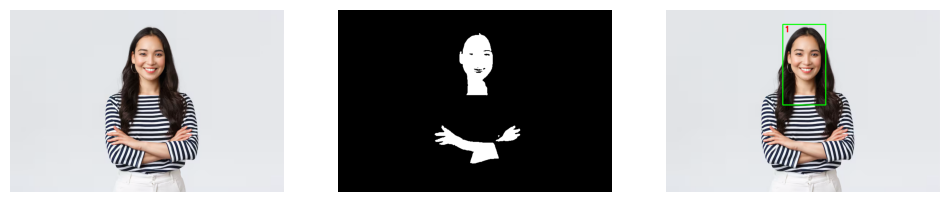

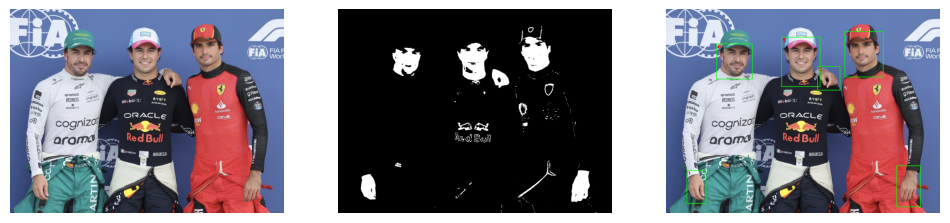

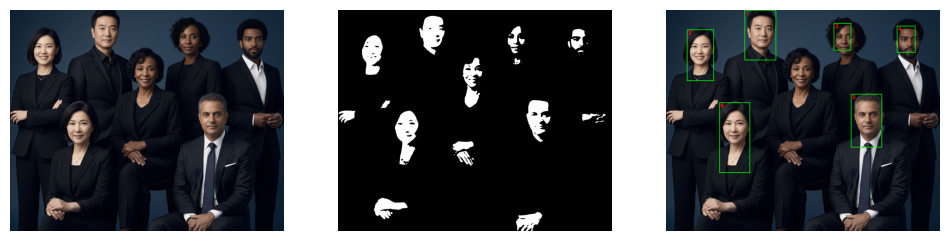

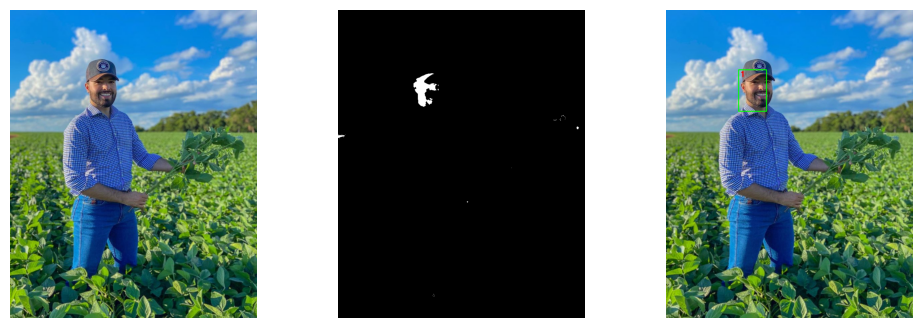

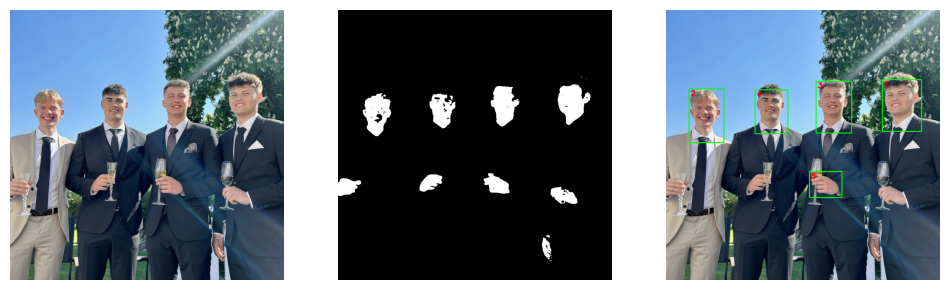

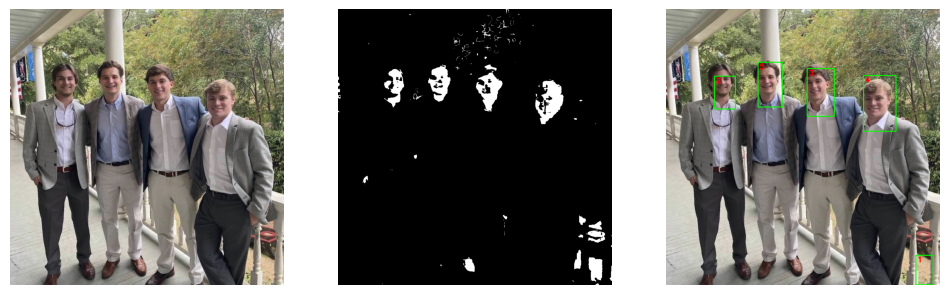

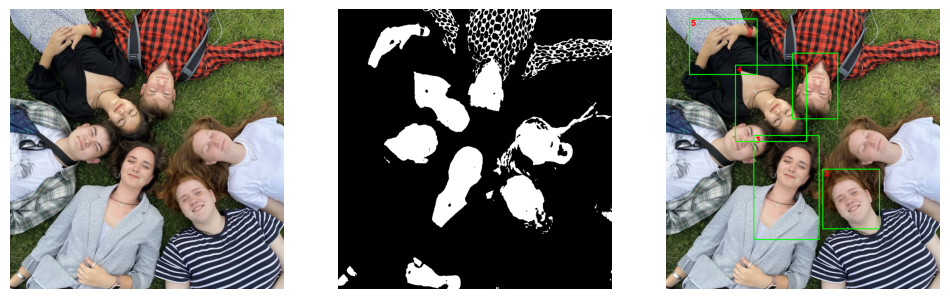

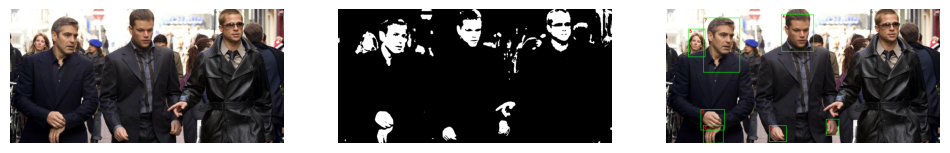

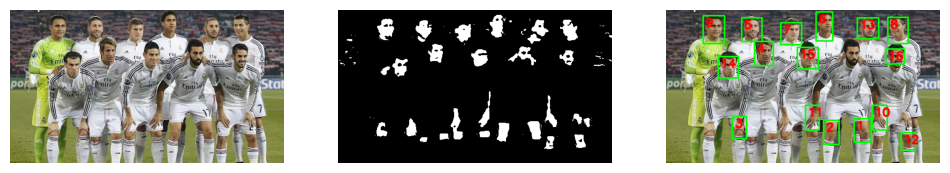

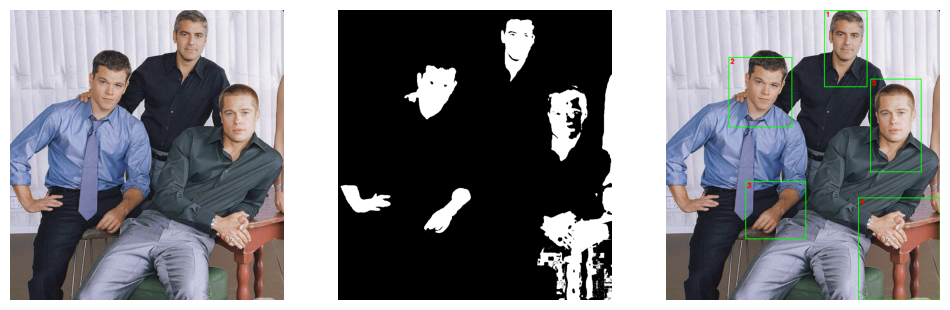

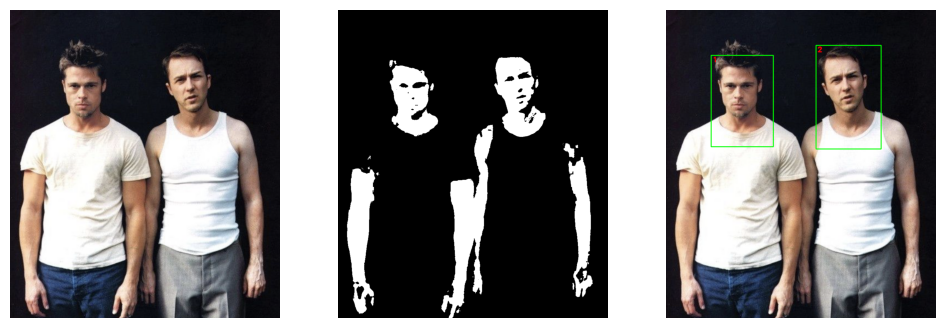

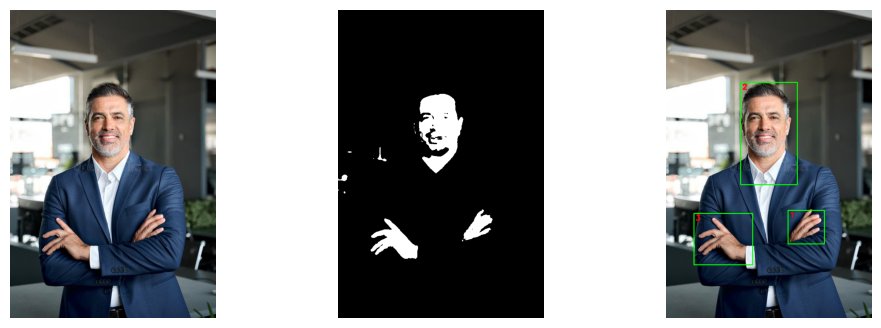

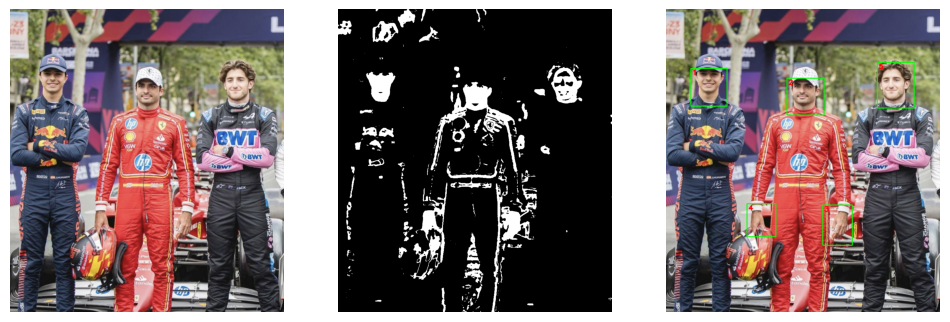

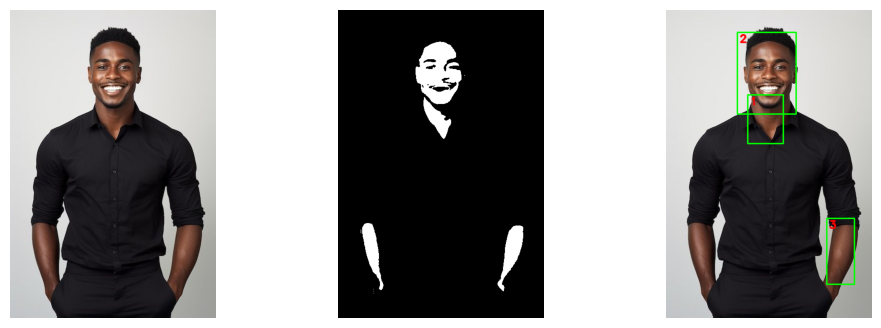

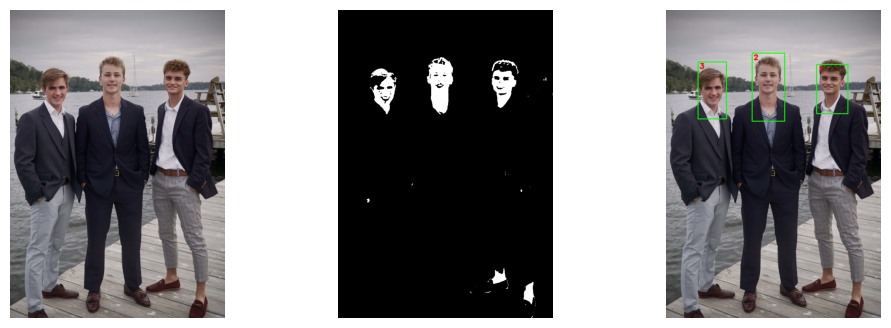

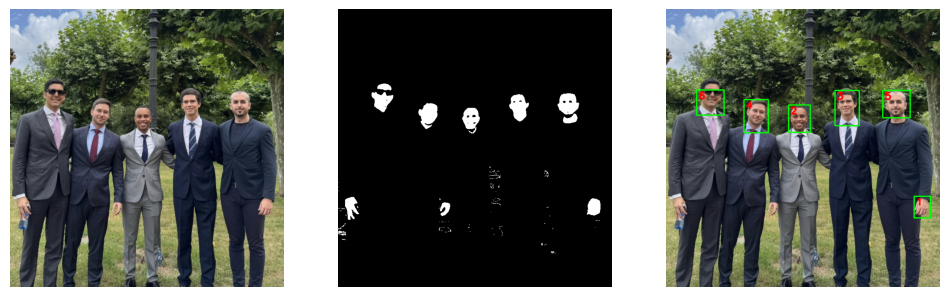

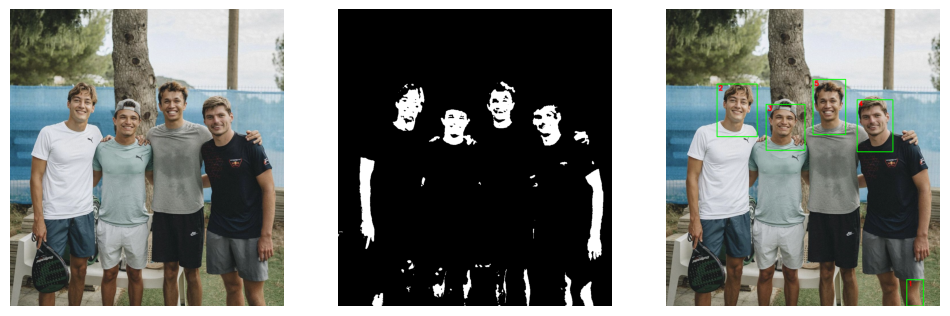

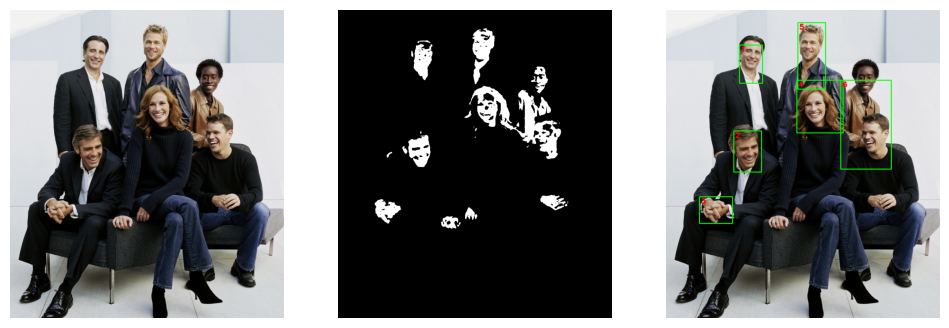

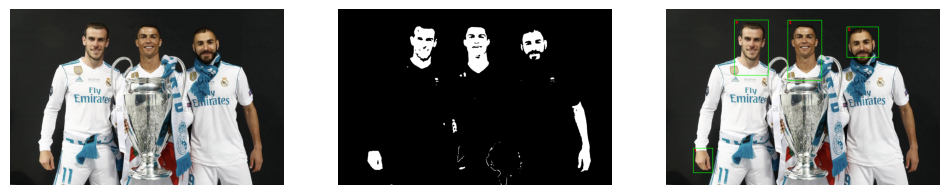

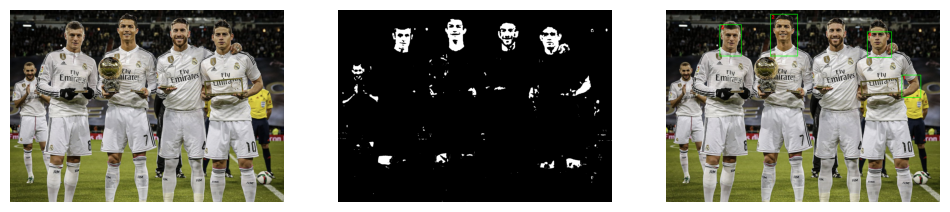

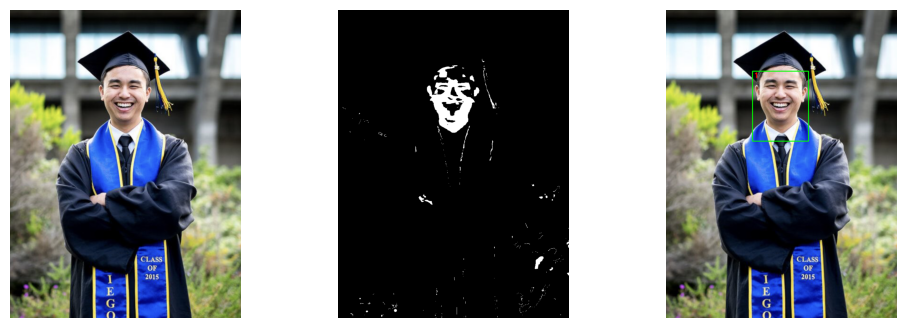

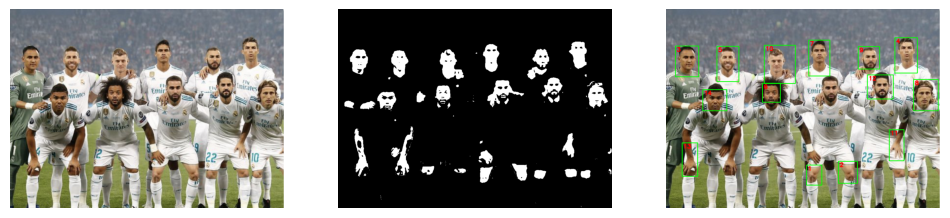

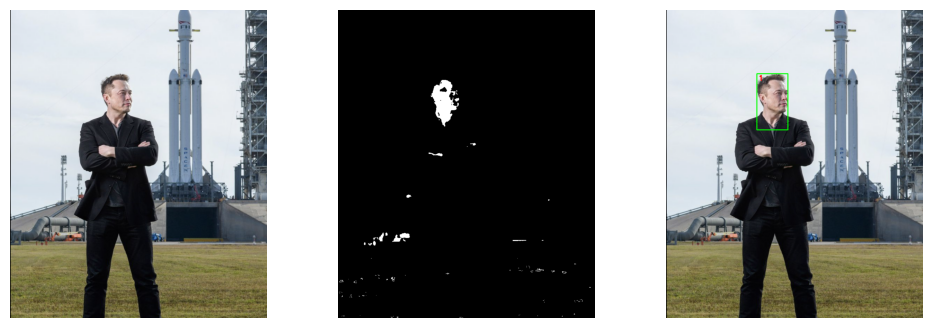

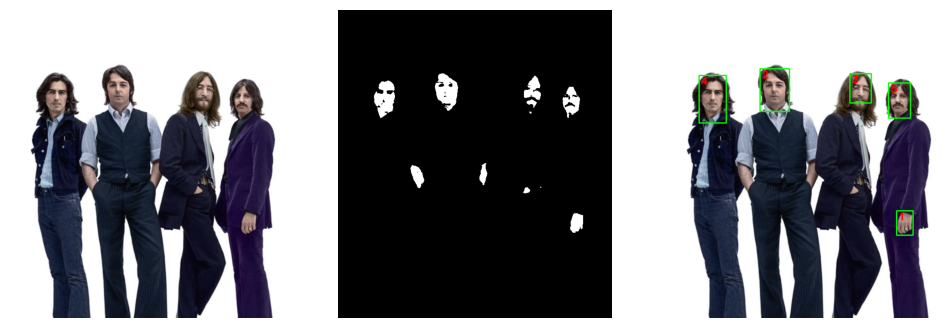

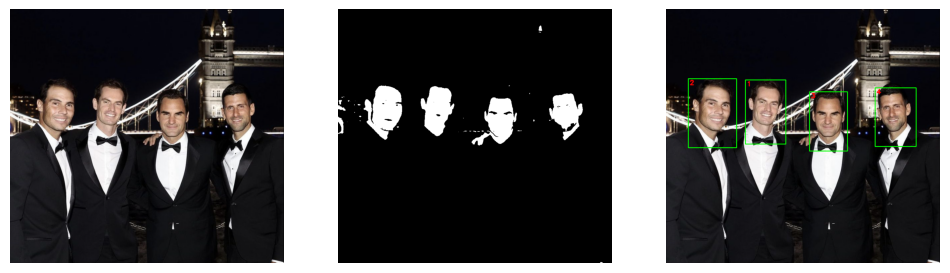

In [73]:
# Ejemplo con apply_blur=False para ver que tal funciona la detección.

for i in range(1, 26):
    det = SimpleSkinMaskDetector()
    det.process(f'multiple_face/im{i}.png', apply_blur=False)

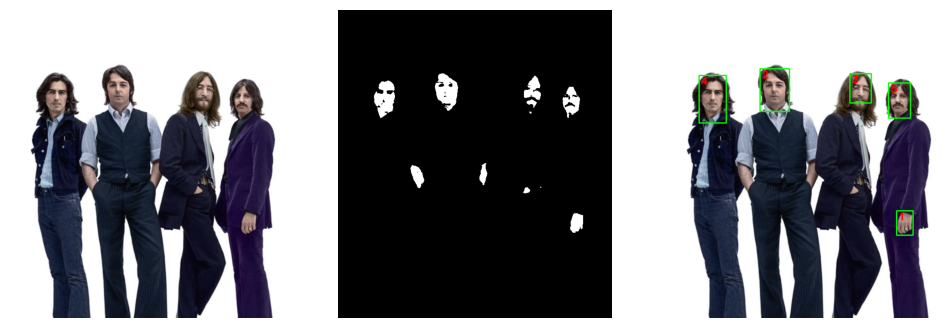

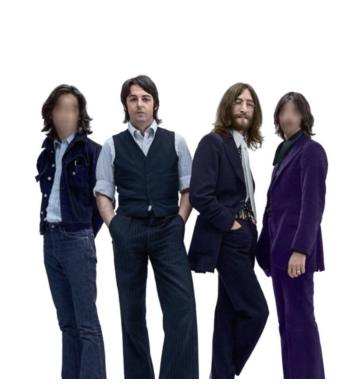

In [77]:
# Ejemplo con difuminado selectivo

det = SimpleSkinMaskDetector()
det.process(f'multiple_face/im{24}.png', apply_blur=True)

Con esto habríamos cumplido con el objetivo de la práctica. La realidad es que el funcionamiento es bastante bueno y hay un recall muy alto y unos falsos positivos aceptables. Sin embargo, hemos querido saber cual es el límite de nuestras posibilidades con estas herramientas y este tiempo. Tras numerosas pruebas con este algoritmo, probando todo tipo de parámetros, operaciones morfológicas más agresivas o una búsqueda distinta de candidatos, los resultados no han mejorado. **¿Es esto todo lo que podemos conseguir sin usar redes neuronales y sin un método matemático inabarcable para nuestro tiempo y nivel?**

Para responder a esta pregunta, hemos creado una segunda aproximación muy distinta a esta. Por simplicidad y evitar la redundancia, consideraremos esta implementación como la final para hacer selección y en la otra, si el parámetro `apply_blur=True`, se distorsionarán todas las caras reconocidas (repetimos que añadir otro parámetro para que también realizase selección sería trivial y no lo hacemos por simplicidad). Esto lo haremos con el objetivo de poder aplicarlo a vídeos y el tiempo real de nuestra propia webcam. El algoritmo puede encontrarse en `selector2.ipynb`.